# 2. Modelo de Constraint Programming

Fase 2: del JSON a la solución con OR-Tools CP-SAT. Modelo formal, variantes y resultados en `docs/fase2_solver.md`.

**Modelo base (M1).** Para cada celda blanca $c$: $x_c \in \{1,\dots,9\}$. Para cada tramo $r$ con celdas $C_r$ y suma $s_r$:

$$\text{AllDifferent}(x_c : c \in C_r) \qquad \sum_{c \in C_r} x_c = s_r$$

In [1]:
import os, sys
from pathlib import Path
# ejecutar desde la raíz del repositorio para que funcionen los imports de src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show(*imgs, titles=None, size=4.5, cmap="gray"):
    fig, axes = plt.subplots(1, len(imgs), figsize=(size * len(imgs), size))
    axes = np.atleast_1d(axes)
    for k, (ax, im) in enumerate(zip(axes, imgs)):
        ax.imshow(im, cmap=cmap if im.ndim == 2 else None)
        ax.set_title(titles[k] if titles else "", fontsize=10, loc="left")
        ax.axis("off")
    plt.tight_layout(); plt.show()

In [2]:
from src.solver.parse import load_puzzle, validate
from src.solver.__main__ import render
from src.solver.solve import solve_puzzle, SolveResult

puzzle = load_puzzle("data/puzzles/p02_square_6x6.json")
print(f"{puzzle.rows}x{puzzle.cols}: {len(puzzle.white)} variables, {len(puzzle.runs)} tramos")
print("validación:", validate(puzzle))
print(render(puzzle, SolveResult("-", "-")))

6x6: 20 variables, 15 tramos
validación: ValidationReport(errors=[], warnings=[])
  ###  |  16\  |  25\  |  ###  |  12\  |   4\  
  \13  |   .   |   .   |  17\5 |   .   |   .   
  \30  |   .   |   .   |   .   |   .   |   .   
  ###  |  4\10 |   .   |   .   |   4\  |  11\  
  \24  |   .   |   .   |   .   |   .   |   .   
   \4  |   .   |   .   |   \7  |   .   |   .   


## Combinaciones válidas (base de M2 y M3)

Un tramo de longitud $L$ y suma $s$ solo admite ciertos conjuntos de dígitos. **M2** reduce cada dominio a la intersección de los dígitos permitidos por sus dos tramos; **M3** añade una tabla de combinaciones sobre booleanos de uso (con canalización reificada $y_{c,d} \Leftrightarrow x_c = d$).

In [3]:
from src.solver.combos import valid_combinations, allowed_digits
for L, s in [(2, 3), (2, 10), (3, 23), (4, 10), (5, 25)]:
    combos = [sorted(c) for c in valid_combinations(L, s)]
    print(f"L={L} s={s:>2}: {combos[:5]}{' ...' if len(combos) > 5 else ''}   dígitos posibles {sorted(allowed_digits(L, {s}))}")

L=2 s= 3: [[1, 2]]   dígitos posibles [1, 2]
L=2 s=10: [[1, 9], [2, 8], [3, 7], [4, 6]]   dígitos posibles [1, 2, 3, 4, 6, 7, 8, 9]
L=3 s=23: [[6, 8, 9]]   dígitos posibles [6, 8, 9]
L=4 s=10: [[1, 2, 3, 4]]   dígitos posibles [1, 2, 3, 4]
L=5 s=25: [[1, 2, 5, 8, 9], [1, 2, 6, 7, 9], [1, 3, 4, 8, 9], [1, 3, 5, 7, 9], [1, 3, 6, 7, 8]] ...   dígitos posibles [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
from src.solver.model import build_model
rows = []
for v in ("M1", "M2", "M3"):
    km = build_model(puzzle, v)
    space = sum(np.log10(len(d)) for d in km.domains.values())
    r = solve_puzzle(puzzle, variant=v)
    rows.append((v, len(km.model.Proto().variables), len(km.model.Proto().constraints), space,
                 r.stats["wall_time_s"] * 1000, r.unique))
print(f"{'variante':<9}{'variables':>10}{'restricc.':>10}{'log10 espacio':>15}{'ms':>8}  única")
for v, nv, nc, sp, ms, u in rows:
    print(f"{v:<9}{nv:>10}{nc:>10}{sp:>15.1f}{ms:>8.1f}  {u}")
print()
print(render(puzzle, solve_puzzle(puzzle, variant="M2")))

variante  variables restricc.  log10 espacio      ms  única
M1               20        30           19.1    17.2  True
M2               20        30           11.8    11.9  True
M3              252       394           11.8     6.7  True

  ###  |  16\  |  25\  |  ###  |  12\  |   4\  
  \13  |   7   |   6   |  17\5 |   4   |   1   
  \30  |   9   |   4   |   6   |   8   |   3   
  ###  |  4\10 |   7   |   3   |   4\  |  11\  
  \24  |   3   |   5   |   8   |   1   |   7   
   \4  |   1   |   3   |   \7  |   3   |   4   


## Restricciones reificadas

El modelo base no las necesita (todas las reglas son incondicionales). Se usan donde aportan:

1. **Unicidad**: se vuelve a resolver exigiendo $\bigvee_c (x_c \neq v_c)$; si es infactible, la solución es única.
2. **Corrección de OCR**: para una pista dudosa, $z_k \Rightarrow \sum x_c = v_k$, con $\sum_k z_k = 1$, maximizando $\sum z_k \log p_k$.

Ejemplo: el OCR leyó **11** donde decía **17** (confusión 1↔7) y creyó más en el 11.

In [5]:
import json
from src.solver.parse import parse_puzzle
with open("data/puzzles/p02_square_6x6.json", encoding="utf-8") as f:
    data = json.load(f)
data["grid"][1][3]["down"] = 11
data["uncertain_clues"] = [{"row": 1, "col": 3, "dir": "down",
                            "candidates": [{"value": 11, "p": 0.7}, {"value": 17, "p": 0.3}]}]
r = solve_puzzle(parse_puzzle(data))
print("sin corrección:", solve_puzzle(parse_puzzle(data), correct=False).status)
print("con corrección:", r.status, r.corrected_clues, "| única:", r.unique)

sin corrección: INFEASIBLE
con corrección: OPTIMAL [{'row': 1, 'col': 3, 'dir': 'down', 'from': 11, 'to': 17}] | única: True


## Diagnóstico de infactibilidad

Con un literal de supuesto por cada suma, CP-SAT devuelve un subconjunto de pistas que explica el conflicto.

In [6]:
bad = load_puzzle("data/puzzles/p04_infeasible_3x3.json")
r = solve_puzzle(bad)
print(render(bad, r)); print(r.status, "-> tramos en conflicto:", r.conflicts)

  ###  |   4\  |  16\  
   \3  |   .   |   .   
  \17  |   .   |   .   
INFEASIBLE -> tramos en conflicto: [{'row': 0, 'col': 2, 'dir': 'down', 'total': 16}, {'row': 1, 'col': 0, 'dir': 'right', 'total': 3}]


## Escalabilidad

Resultados de `python -m src.eval.bench_solver` (puzzles sintéticos de 6×6 a 30×30). Si no existen, se ejecuta una versión corta.

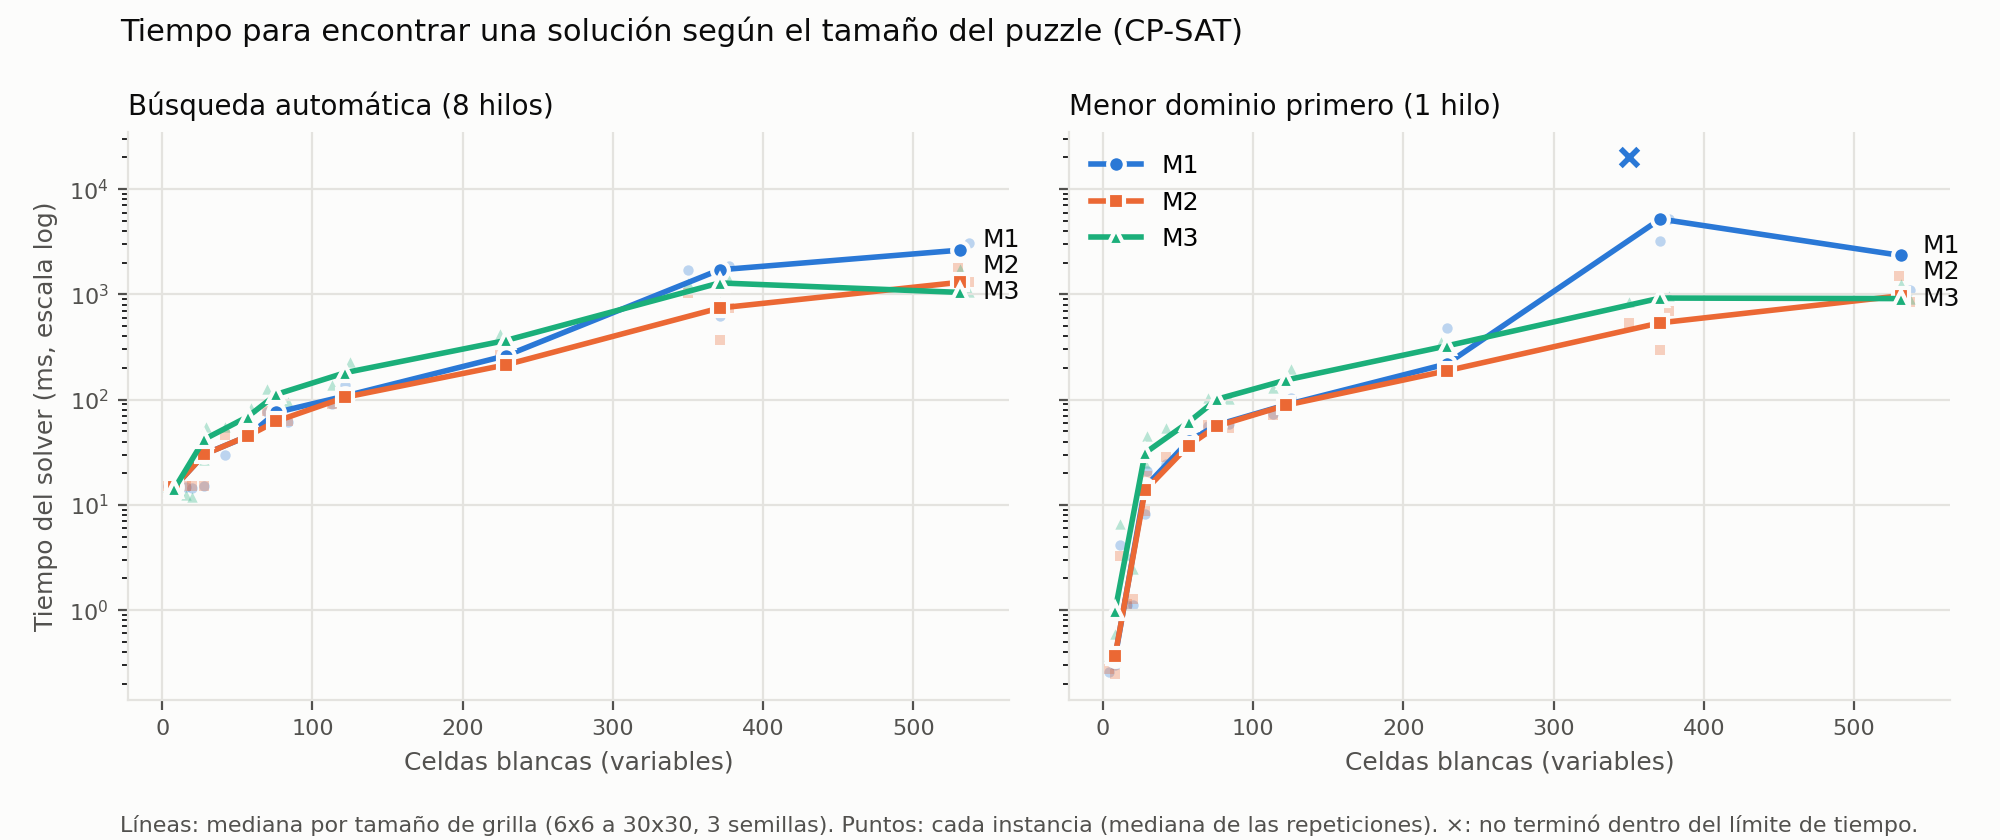

M1: mediana 84 ms, máximo 3104 ms
M2: mediana 84 ms, máximo 1785 ms
M3: mediana 133 ms, máximo 1758 ms


In [7]:
import csv, statistics, subprocess
summary = Path("outputs/bench/solver_summary.csv")
if not summary.exists():
    subprocess.run([sys.executable, "-m", "src.eval.bench_solver", "--repeats", "1"], check=True, capture_output=True)
rows = list(csv.DictReader(open(summary, encoding="utf-8")))
from IPython.display import Image, display
display(Image("outputs/bench/solver_time.png", width=900))
for v in ("M1", "M2", "M3"):
    t = [float(r["time_ms_median"]) for r in rows if r["variant"] == v and r["search"] == "auto" and r["instance"].startswith("gen_")]
    print(f"{v}: mediana {statistics.median(t):.0f} ms, máximo {max(t):.0f} ms")